In [13]:
#so in this case we are gonna use some large amoutn of dataset to build a larger model which has more than 1 features
# for this we use medical cost dataset in kaggele whihc is mainly about insurance data
#import the dataset and build the machine learning model

#importing required libraries for this model building

import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
#read the isnurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

#so we have successfully imported our dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
#dan methandi sex, region wage categorical (numerical nowana) variables model ek trian krddi use krnna nm ewa numerical krnna one eka krnna tami api me pandas eke get_dummies method ek use krla krganne

insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head(10)


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,False,True,False
6,46,33.440,1,8240.58960,True,False,True,False,False,False,True,False
7,37,27.740,3,7281.50560,True,False,True,False,False,True,False,False
8,37,29.830,2,6406.41070,False,True,True,False,True,False,False,False
9,60,25.840,0,28923.13692,True,False,True,False,False,True,False,False


In [8]:
# so now we are ready to do our model building work step by step

# 1. Create x,y values ( features and labels )

# meke dna values gannkot acharges natuwa anik columns gnnwa mokda api predic tkrnna yanne charges neg

x = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]



In [9]:
#ltes view x and y first
x.head(), y.head()

(   age     bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
 0   19  27.900         0        True     False      False        True   
 1   18  33.770         1       False      True       True       False   
 2   28  33.000         3       False      True       True       False   
 3   33  22.705         0       False      True       True       False   
 4   32  28.880         0       False      True       True       False   
 
    region_northeast  region_northwest  region_southeast  region_southwest  
 0             False             False             False              True  
 1             False             False              True             False  
 2             False             False              True             False  
 3             False              True             False             False  
 4             False              True             False             False  ,
 0    16884.92400
 1     1725.55230
 2     4449.46200
 3    21984.47061
 4     3866.85520
 

In [10]:
# 2. create training and test sets

#dan metna trian sets and test sets wen krgnna api use krgnnwa scikitlearn train test split functionality eka

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
len(x), len(x_train), len(x_test)


(1338, 1070, 268)

In [15]:
# 3. build a neural network (sort of like model_2 above lesons)
#me dnna one model ekath ara kalin hdpu model_2 eka wage tami

tf.random.set_seed(42)

insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=["mae"])

insurance_model.fit(x_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10193.9766 - mae: 10193.9766
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7575.5576 - mae: 7575.5576 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7566.6025 - mae: 7566.6025 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7738.2427 - mae: 7738.2427
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7283.1382 - mae: 7283.1382
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7532.5215 - mae: 7532.5215 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7591.8711 - mae: 7591.8711 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7322.3257 - mae: 7322.3257
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7949.4238 - mae: 7949.4238 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7309.9180 - mae: 7309.9180
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7188.1313 - mae: 7188.1313 
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2

In [16]:
#check te result of te insurance model on test data
insurance_model.evaluate(x_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6425.7578 - mae: 6425.7578  


[6203.35546875, 6203.35546875]

In [17]:
# now lets check the results by looking at the median and mean
y_train.median(), y_train.mean()

(9575.4421, np.float64(13346.089736364485))

In [23]:
# as per now the model is not performing too well

#so in this case to improve our model we will run 2 experiments :

#1. add extra layer with more hidden units and adam as optimizer
#2. train for longer
#3. insert your own experiment

#1

tf.random.set_seed(42)

insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])
insurance_model_2.fit(x_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13275.3076 - mae: 13275.3076
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13133.5000 - mae: 13133.5000
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12843.8613 - mae: 12843.8613
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12258.2324 - mae: 12258.2324 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11225.9785 - mae: 11225.9785
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9805.3018 - mae: 9805.3018
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8384.8232 - mae: 8384.8232
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7559.9072 - mae: 7559.9072
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7411.5791 - mae: 7411.5791
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7382.6587 - mae: 7382.6587
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7361.3652 - mae: 7361.3652
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0

In [24]:
#now lets build the 3rd model

tf.random.set_seed(42)

insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),

])

insurance_model_3.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

history = insurance_model_3.fit(x_train, y_train, epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13283.3486 - mae: 13283.3486
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13154.4473 - mae: 13154.4473 
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12896.2588 - mae: 12896.2588
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12369.8135 - mae: 12369.8135
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11430.4316 - mae: 11430.4316
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10074.2930 - mae: 10074.2930
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8624.0381 - mae: 8624.0381
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7635.9321 - mae: 7635.9321
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7407.0225 - mae: 7407.0225
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7371.1562 - mae: 7371.1562
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7350.4028 - mae: 7350.4028
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━

In [25]:
insurance_model_3.evaluate(x_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3487.5491 - mae: 3487.5491  


[3420.19140625, 3420.19140625]

Text(0.5, 0, 'epochs')

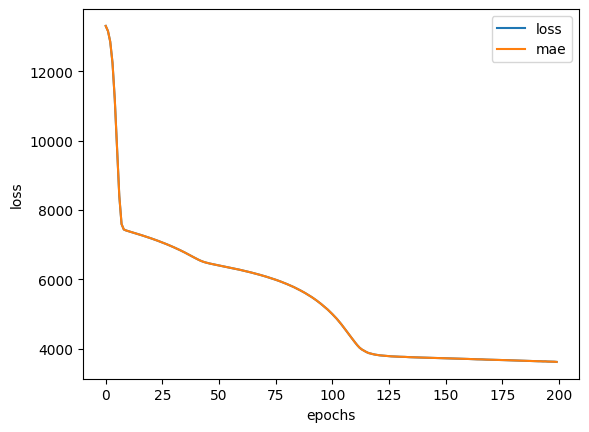

In [27]:
#lets see what is meant by hostory variable we declared in the model_3 training

pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
#this is a  good visulizing technique and this should be used when im building the research project

In [28]:
# Question ghow long should we trian the model for?

#it actually depends. really... it depends on the problem you are working on, however, many people have asked this question before so tensorflow has a solution, it is called ealrystopping callback


<Axes: ylabel='Frequency'>

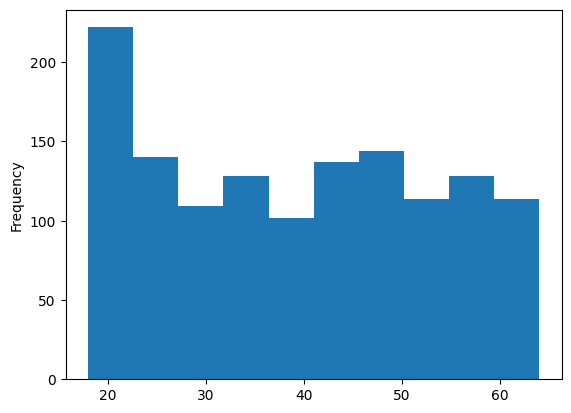

In [30]:
#NORMALIZATION AND PREPROCESSING

# lets plot age column in our dataset

x["age"].plot(kind="hist")

<Axes: ylabel='Frequency'>

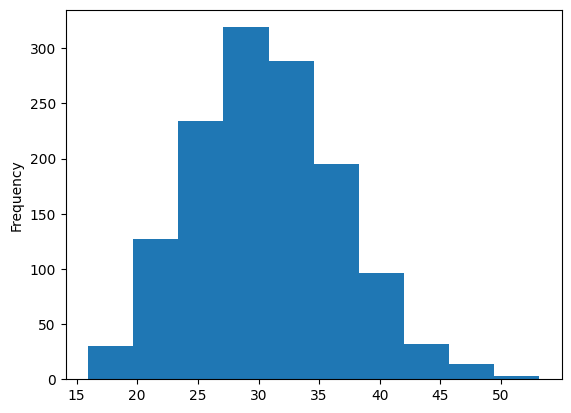

In [31]:
# niow lets check bmi column
x["bmi"].plot(kind="hist")

In [1]:
# in terms of scaling values, neural networks tend to prefer normalization.
#if you are not sure on which one to use, you could try both and see which one performs better

#lets see a example

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

insurance_normalized = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance_normalized

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
#to prepare our data, we can borrow a few classes form scikit-learn
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

#create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), # turn all values in these coluns between 0,1
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

#create X and Y values
x1 = insurance_normalized.drop("charges", axis=1)
y1 = insurance_normalized["charges"]

# build our trian and test sets
x_train, x_test, y_train, y_test = train_test_split(x1,y1, test_size=0.2, random_state=42)

#for the column transformer to our training data
ct.fit(x_train)

#transform training and test data with normalization (minmaxscaler) and onehotencoder
x_train_normal = ct.transform(x_train)
x_test_normal = ct.transform(x_test)

In [11]:
#lets see our data when we first initialized it
x_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [10]:
#what does our data look like now
x_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [13]:
#lets see the shapes
x_train_normal.shape, x_train.shape

((1070, 11), (1070, 6))

In [15]:
#now our data has been normalized and one hot encoded and now we can build a neural network model on it and see how it goes

tf.random.set_seed(42)

insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_4.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

insurance_model_4.fit(x_train_normal, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 13297.0234 - mae: 13297.0234
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13289.8037 - mae: 13289.8037
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13271.0674 - mae: 13271.0674
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13230.5771 - mae: 13230.5771
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13157.6670 - mae: 13157.6670
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13041.7158 - mae: 13041.7158
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12872.4170 - mae: 12872.4170
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12639.6758 - mae: 12639.6758
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12333.6367 - mae: 12333.6367
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11947.7031 - mae: 11947.7031
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11488.4150 - mae: 11488.4150
Epoch 12/100
34/34 ━━━━━━━━━━━

In [16]:
#now lets evaluate our insurance model trianed on normalized data
insurance_model_4.evaluate(x_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3512.4189 - mae: 3512.4189  


[3426.965087890625, 3426.965087890625]